In [18]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [19]:
# =====================================================
# RUTAS
# =====================================================

DATASET_PATH = "dataset/"
TRAIN_PATH = os.path.join(DATASET_PATH, "Training")

RUTAS = {
    "Original": os.path.join(TRAIN_PATH, "s1"),

    "LR x2": "dataset/Training_LR_escala2/s1",
    "CLAHE x2": "dataset/CLAHE/Training_CLAHE_escala2/s1",
    "SRCNN x2": "dataset/Super_resolution/Training_SR_escala2/s1",

    "LR x4": "dataset/Training_LR_escala4/s1",
    "CLAHE x4": "dataset/CLAHE/Training_CLAHE_escala4/s1",
    "SRCNN x4": "dataset/Super_resolution/Training_SR_escala4/s1"
}

ETIQUETAS = [
    "Original",
    "LR (Escala ×2)",
    "CLAHE (Escala ×2)",
    "SRCNN (Escala ×2)",
    "LR (Escala ×4)",
    "CLAHE (Escala ×4)",
    "SRCNN (Escala ×4)"
]


In [20]:
# =====================================================
# ARCHIVOS
# =====================================================

archivos = sorted([
    f for f in os.listdir(RUTAS["Original"])
    if f.lower().endswith(".pgm")
])

num_imgs = min(5, len(archivos))

print("Cantidad de imágenes:", len(archivos))
print("Mostrando:", num_imgs)


Cantidad de imágenes: 9
Mostrando: 5


Tipo axes: <class 'numpy.ndarray'>
Shape axes: (7, 5)


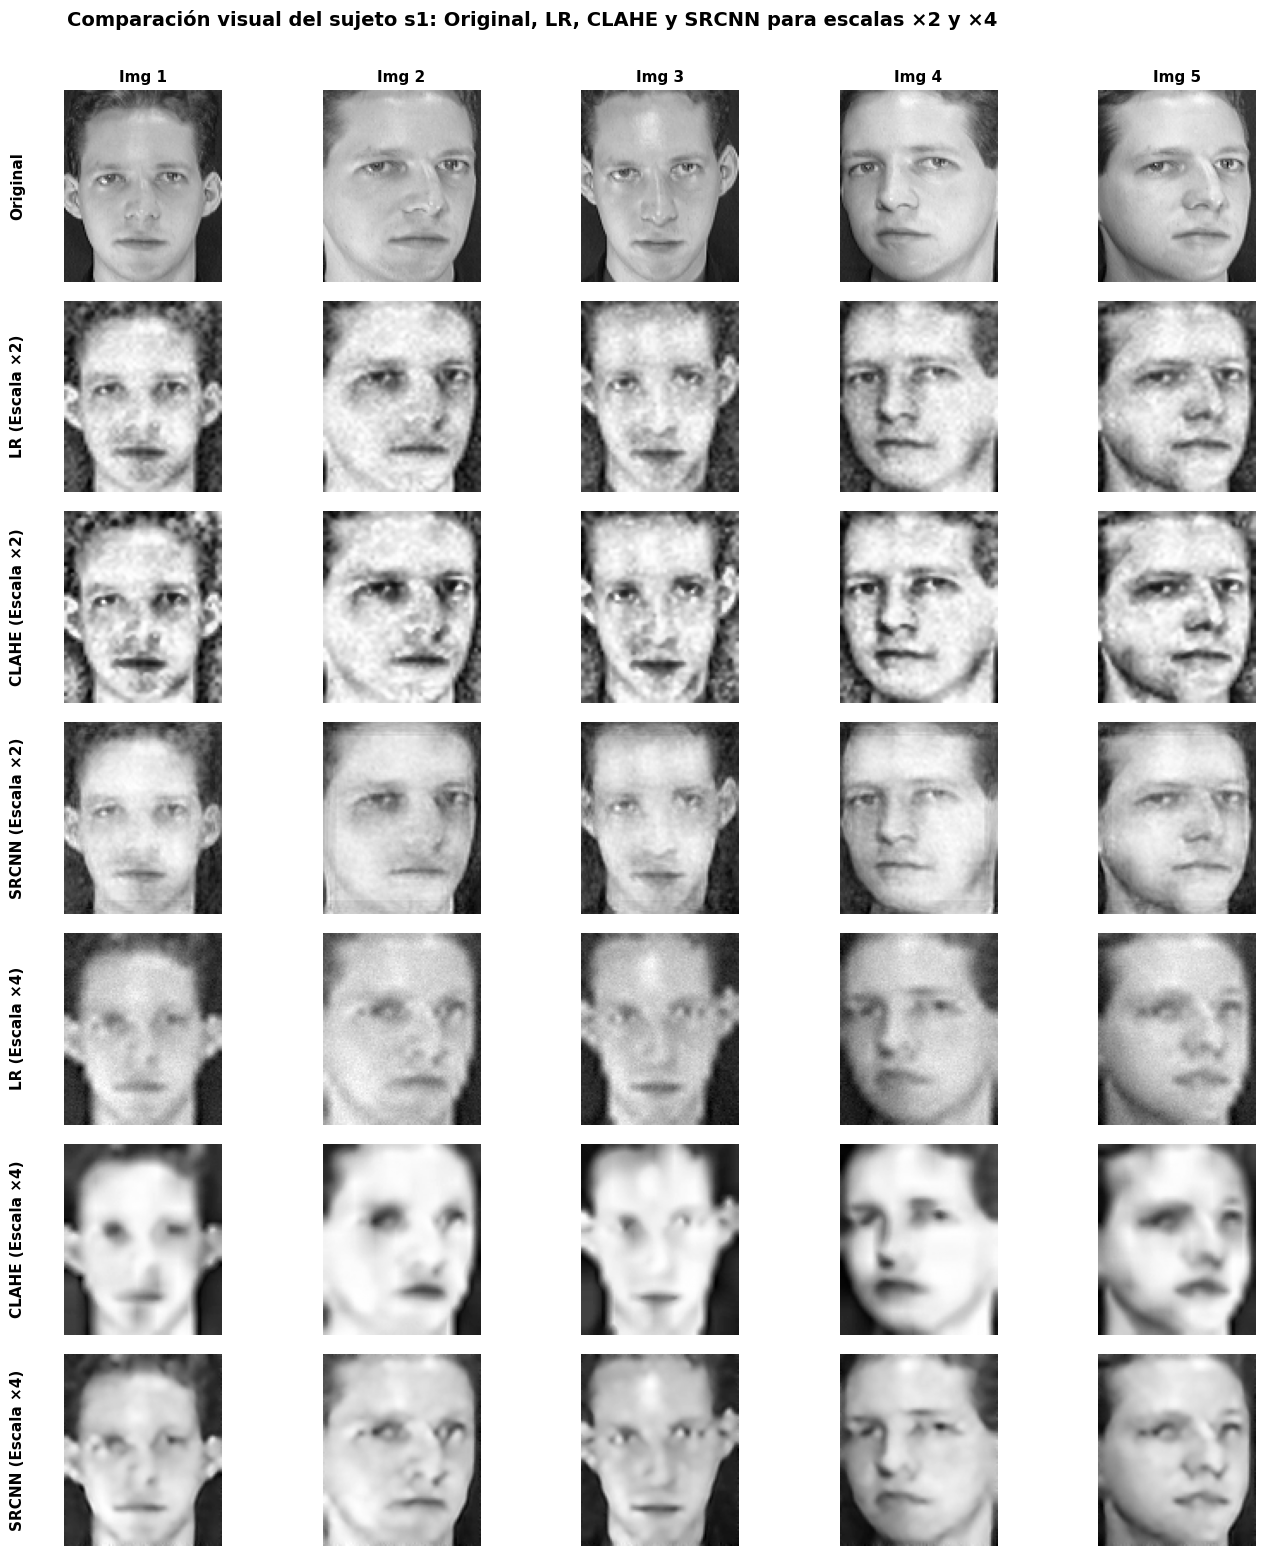

In [23]:
# =====================================================
# FIGURA
# =====================================================

fig, axes = plt.subplots(
    nrows=7,
    ncols=num_imgs,
    figsize=(16, 16)
)

print("Tipo axes:", type(axes))
print("Shape axes:", axes.shape)

plt.subplots_adjust(
    left=0.18,
    top=0.93,
    bottom=0.02,
    right=0.98,
    hspace=0.1,
    wspace=0.05
)

# =====================================================
# MOSTRAR IMÁGENES
# =====================================================

for fila, ((nombre, ruta_base), etiqueta) in enumerate(
        zip(RUTAS.items(), ETIQUETAS)):

    for col in range(num_imgs):

        archivo_original = archivos[col]
        nombre_base = os.path.splitext(archivo_original)[0]

        if nombre == "Original":
            archivo_actual = nombre_base + ".pgm"
        else:
            archivo_actual = nombre_base + ".png"

        ruta_img = os.path.join(ruta_base, archivo_actual)

        img = cv2.imread(ruta_img, cv2.IMREAD_GRAYSCALE)

        if img is None:
            print("ERROR AL LEER:", ruta_img)
            continue

        # Forzar ndarray uint8
        img = np.asarray(img, dtype=np.uint8)

        ax = axes[fila, col]

        try:
            ax.imshow(img, cmap="gray")
        except Exception as e:
            print("\n===== ERROR DETECTADO =====")
            print("Fila:", fila)
            print("Columna:", col)
            print("Ruta:", ruta_img)
            print("Tipo:", type(img))
            print("dtype:", img.dtype)
            print("shape:", img.shape)
            raise e

        ax.axis("off")

        if fila == 0:
            ax.set_title(
                f"Img {col+1}",
                fontsize=11,
                fontweight="bold"
            )

        if col == 0:
            ax.text(
                x=-0.25,
                y=0.5,
                s=etiqueta,
                fontsize=11,
                fontweight="bold",
                ha="right",
                va="center",
                rotation=90,
                transform=ax.transAxes
            )

plt.suptitle(
    "Comparación visual del sujeto s1: Original, LR, CLAHE y SRCNN para escalas ×2 y ×4",
    fontsize=14,
    fontweight="bold"
)
plt.show()